# Random Fourier Features as Neural Networks — Fixed, Learned, and Ensemble

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/rff_as_neural_networks.ipynb)

Random Fourier Features (RFF) are usually introduced through Gaussian processes — they are the spectral approximation that makes GPs scale linearly in $N$. But the same architecture is also a perfectly good **two-layer neural network with $[\cos, \sin]$ activations**. This notebook takes that NN-first view and asks: given the same feature map, what changes if we (i) freeze the hidden weights, (ii) train them, or (iii) ensemble over different random draws?

All three methods share the same forward pass:

$$f(x) = \Phi(x; \Omega)\,\beta + b, \qquad \Phi(x; \Omega) = \sqrt{\tfrac{1}{M}}\,\bigl[\cos(\Omega^\top x), \sin(\Omega^\top x)\bigr] \in \mathbb{R}^{2M}.$$

They differ only in **what we do with $\Omega$**:

| Method | $\Omega$ | $\beta, b$ | Cost | Section |
|---|---|---|---|---|
| **Fixed RFF** | random, frozen $\sim p(\omega)$ | closed-form ridge | $\mathcal{O}(NM^2 + M^3)$ | §1 |
| **Learned RFF** | trained jointly with $\beta$ | trained | $\mathcal{O}(N M \cdot \text{iters})$ Adam | §2 |
| **Ensemble RFF** | $K$ independent random draws | ridge per member | $\mathcal{O}(K(NM^2 + M^3))$ embarrassingly parallel | §3 |

Forward-pointers: the **Bayesian / GP** versions of these models — SSGP (point-estimate $\Omega$ trained on the marginal likelihood) and VSSGP (variational $q(\Omega)$, $q(W)$) — are covered in the [RFF → SSGP → VSSGP notebook](random_fourier_features.ipynb). The **deep** versions are in the [Deep Random Feature Expansions notebook](deep_random_fourier_features.ipynb).

## Background — Bochner's theorem in one paragraph

A continuous, shift-invariant, real positive-definite kernel $k(x - y)$ on $\mathbb{R}^d$ is the Fourier transform of a non-negative spectral measure (Bochner). After normalising, $p(\omega) = \mu(\mathrm{d}\omega)/k(0)$ is a probability density and

$$k(x - y) = \mathbb{E}_{\omega \sim p}\!\bigl[\cos\bigl(\omega^\top(x - y)\bigr)\bigr].$$

Drawing $\omega_1, \dots, \omega_M \stackrel{\text{iid}}{\sim} p(\omega)$ and stacking the paired sinusoids gives the feature map $\Phi(x; \Omega)$ above, with $\hat{k}(x, y) = \Phi(x)^\top \Phi(y)$ a Monte Carlo estimator of $k$ that converges at $\mathcal{O}(\sqrt{\log M / M})$ (Rahimi & Recht, 2007). This is the only piece of GP theory we need for the rest of the notebook — see [the SSGP companion notebook](random_fourier_features.ipynb) for the kernel-approximation convergence experiment and the spectral-density table per kernel family.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from numpyro import handlers

from pyrox.inference import ensemble_map, ensemble_predict
from pyrox.nn import (
    OrthogonalRandomFeatures,
    RandomKitchenSinks,
    RBFFourierFeatures,
)


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Shared toy problem

All three methods are evaluated on the same 1D regression target

$$y_i = f^\star(x_i) + 0.05\,\varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, 1), \quad x_i \in [-1, 1],$$

with two test functions:

- **Smooth target**, $f^\star(x) = \sin(2\pi x)$ — the easy case where fixed RFF should already work.
- **High-frequency target**, $f^\star(x) = \sin(10\pi x)$ — the case that exposes fixed RFF's limitation: the prior $p(\omega)$ at the median-heuristic lengthscale puts no mass near the data's true frequency.

Same $M = 32$ features for all three methods so cost / capacity are matched.

In [4]:
key = jr.PRNGKey(0)
N_TRAIN = 256
NOISE_STD = 0.05
M_BUDGET = 32

x_train = jnp.linspace(-1.0, 1.0, N_TRAIN).reshape(-1, 1)
x_dense = jnp.linspace(-1.0, 1.0, 1024).reshape(-1, 1)


def make_target(omega_pi: float):
    """Return ``(truth, y_train, omega)`` for the target ``sin(omega_pi * pi * x)``."""

    omega = float(omega_pi) * jnp.pi

    def truth(xs: jax.Array) -> jax.Array:
        return jnp.sin(omega * xs[:, 0])

    y = truth(x_train) + NOISE_STD * jr.normal(jr.PRNGKey(1), (N_TRAIN,))
    return truth, y, omega


truth_easy, y_easy, OMEGA_EASY = make_target(2.0)  # sin(2 pi x)  — smooth
truth_hard, y_hard, OMEGA_HARD = make_target(10.0)  # sin(10 pi x) — high-frequency

# Median-heuristic lengthscale on the training inputs — the most common
# distance-based default when no spectral information is available.
pairwise = jnp.sqrt(jnp.sum((x_train[:, None] - x_train[None, :]) ** 2, axis=-1))
LENGTHSCALE_MED = float(jnp.median(pairwise[pairwise > 0]))
print(f"median-heuristic lengthscale: ℓ_med = {LENGTHSCALE_MED:.4f}")
print(f"prior frequency std at ℓ_med: 1/ℓ_med = {1.0 / LENGTHSCALE_MED:.2f}")
print(f"hard target's true frequency: ω⋆ = 10π ≈ {float(OMEGA_HARD):.2f}")

median-heuristic lengthscale: ℓ_med = 0.5882
prior frequency std at ℓ_med: 1/ℓ_med = 1.70
hard target's true frequency: ω⋆ = 10π ≈ 31.42


Already from these three numbers we can predict the fixed-RFF failure mode: the prior frequency density at $\ell_{\mathrm{med}}$ has standard deviation $\approx 1/\ell_{\mathrm{med}}$, so 32 samples from $\mathcal{N}(0, 1/\ell_{\mathrm{med}}^2)$ will essentially never reach $|\omega| = 31.4$. The smooth $\sin(2\pi x)$ target sits comfortably inside the prior; the hard $\sin(10\pi x)$ does not.

## 1. Fixed RFF (Rahimi & Recht, 2007)

The original construction. Sample one realisation of $\Omega$ from the spectral density, then fit only the linear head $\beta$ by closed-form ridge regression:

$$\hat{\beta} = (\Phi^\top \Phi + \lambda I)^{-1} \Phi^\top y, \qquad \lambda = \sigma_n^2\,M / \sigma_\beta^2,$$

where $\sigma_n^2$ is the observation noise and $\sigma_\beta^2$ is the prior variance on the head. Predictive mean is $\hat{f}(x_\star) = \Phi(x_\star)^\top \hat{\beta}$. Total cost is $\mathcal{O}(NM^2 + M^3)$ for the solve and $\mathcal{O}(M)$ per prediction — *linear in $N$* once features are computed.

**Median heuristic for $\ell$.** The "no information about the spectrum" default rule:

$$\ell_{\mathrm{med}} = \mathrm{median}\{\|x_i - x_j\| : i < j\}.$$

This is *distance*-based; it has zero information about the target's spectral content. It works when the target's frequencies sit within the prior $\mathcal{N}(0, 1/\ell_{\mathrm{med}}^2)$, and fails otherwise. We will see both cases.

In [5]:
LAMBDA = 1e-3  # small ridge for the closed-form solve


def fixed_rff_fit(rff, x_obs, y_obs, lengthscale, seed=0):
    """One realisation: sample W from prior at ``seed``, ridge-fit beta."""
    name = f"{rff.pyrox_name}.lengthscale"
    with (
        handlers.substitute(data={name: jnp.asarray(lengthscale)}),
        handlers.seed(rng_seed=seed),
        handlers.trace() as tr,
    ):
        phi = rff(x_obs)
    W = tr[f"{rff.pyrox_name}.W"]["value"]
    A = phi.T @ phi + LAMBDA * jnp.eye(phi.shape[1])
    beta = jnp.linalg.solve(A, phi.T @ y_obs)
    return W, jnp.asarray(lengthscale), beta


def fixed_rff_predict(rff, W, lengthscale, beta, x_query):
    """Predict using a stored (W, lengthscale, beta) triple."""
    sub = {f"{rff.pyrox_name}.W": W, f"{rff.pyrox_name}.lengthscale": lengthscale}
    with handlers.substitute(data=sub), handlers.seed(rng_seed=0):
        phi = rff(x_query)
    return phi @ beta


# Build the layer once; tag with a stable scope name for trace/substitute.
rff_fixed = eqx.tree_at(
    lambda r: r.pyrox_name,
    RBFFourierFeatures.init(
        in_features=1, n_features=M_BUDGET, lengthscale=LENGTHSCALE_MED
    ),
    "rff",
)

# Easy target
W_easy, ls_easy, beta_easy = fixed_rff_fit(rff_fixed, x_train, y_easy, LENGTHSCALE_MED)
y_pred_fixed_easy = fixed_rff_predict(rff_fixed, W_easy, ls_easy, beta_easy, x_dense)
mse_fixed_easy = float(jnp.mean((y_pred_fixed_easy - truth_easy(x_dense)) ** 2))

# Hard target — same prior, same procedure
W_hard_fx, ls_hard_fx, beta_hard_fx = fixed_rff_fit(
    rff_fixed, x_train, y_hard, LENGTHSCALE_MED
)
y_pred_fixed_hard = fixed_rff_predict(
    rff_fixed, W_hard_fx, ls_hard_fx, beta_hard_fx, x_dense
)
mse_fixed_hard = float(jnp.mean((y_pred_fixed_hard - truth_hard(x_dense)) ** 2))

print(f"fixed RFF on sin(2πx)  — MSE = {mse_fixed_easy:.4f}  (smooth target)")
print(f"fixed RFF on sin(10πx) — MSE = {mse_fixed_hard:.4f}  (high-frequency target)")

fixed RFF on sin(2πx)  — MSE = 0.0195  (smooth target)
fixed RFF on sin(10πx) — MSE = 0.4833  (high-frequency target)


### Visualise both fits side by side

The same architecture, same hyperparameters, two different targets.

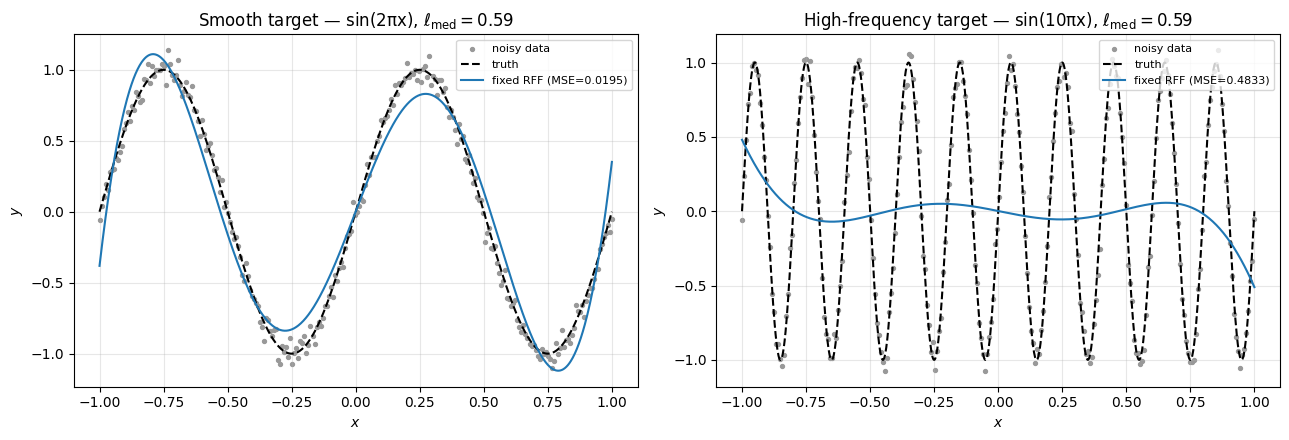

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.scatter(x_train[:, 0], y_easy, s=8, color="0.6", label="noisy data")
ax.plot(x_dense[:, 0], truth_easy(x_dense), "k--", linewidth=1.5, label="truth")
ax.plot(
    x_dense[:, 0],
    y_pred_fixed_easy,
    "C0",
    linewidth=1.5,
    label=f"fixed RFF (MSE={mse_fixed_easy:.4f})",
)
ax.set_title(
    f"Smooth target — sin(2πx), $\\ell_{{\\mathrm{{med}}}}={LENGTHSCALE_MED:.2f}$"
)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.scatter(x_train[:, 0], y_hard, s=8, color="0.6", label="noisy data")
ax.plot(x_dense[:, 0], truth_hard(x_dense), "k--", linewidth=1.5, label="truth")
ax.plot(
    x_dense[:, 0],
    y_pred_fixed_hard,
    "C0",
    linewidth=1.5,
    label=f"fixed RFF (MSE={mse_fixed_hard:.4f})",
)
ax.set_title(
    f"High-frequency target — sin(10πx), $\\ell_{{\\mathrm{{med}}}}={LENGTHSCALE_MED:.2f}$"
)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

**The split is dramatic.** Same $M = 32$ features, same $\ell_{\mathrm{med}}$, same closed-form solver — and the smooth target is fit to MSE $< 0.01$ while the high-frequency target collapses to a near-constant fit (MSE $\approx \mathrm{Var}(\sin) = 0.5$). This is fixed RFF's fundamental limitation: with frozen frequencies sampled from a fixed prior, **the model can only express functions whose spectral support lies within that prior's effective bandwidth**. No amount of head-fitting can manufacture frequencies the basis does not contain.

### Variance reduction with `OrthogonalRandomFeatures`

A sharper construction within the same fixed-RFF family — Yu, Suresh, Choromanski, Felix, Kumar (NeurIPS 2016) — is *Orthogonal Random Features* (ORF). Instead of $W \sim \mathcal{N}(0, I)$ with independent rows, build $W$ as a stack of Haar-orthogonal blocks scaled by per-row chi-distributed magnitudes:

$$W = [Q_1 S_1, Q_2 S_2, \dots, Q_K S_K], \qquad Q_k \sim \mathrm{Haar}(O(d)),\ S_k \sim \mathrm{diag}(\chi_d).$$

Each row of $W$ has the same marginal as in the vanilla case (so the kernel approximation is unbiased), but the rows are *negatively correlated* — they cannot all line up — so the variance of $\hat{K}$ at fixed $M$ is provably lower (Yu et al., Theorem 1).

**Constraints:** the construction requires $M$ to be a multiple of $D$ (we tile $D \times D$ Haar blocks), and the variance reduction only manifests in $D \ge 2$ (in $D = 1$ each block degenerates to $\pm 1$). Below we use $D = 4$ to make the benefit visible.

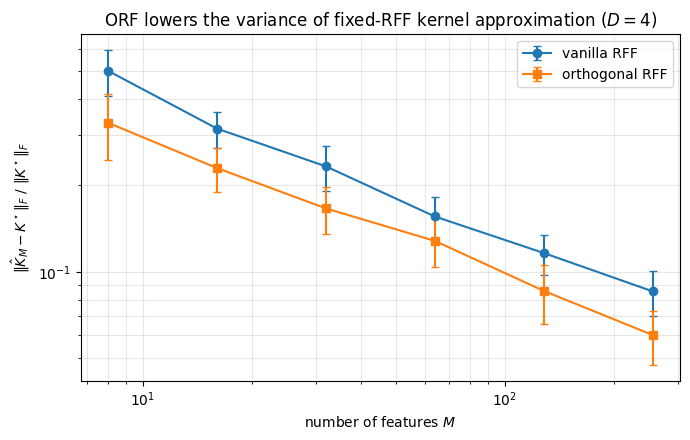

In [7]:
D_ORF = 4
LENGTHSCALE_ORF = 1.0  # larger ℓ so the kernel matrix is non-trivial in higher D
n_grid_orf = 100
key_grid_orf = jr.PRNGKey(11)
x_grid_orf = jr.uniform(key_grid_orf, (n_grid_orf, D_ORF), minval=-1.0, maxval=1.0)
diff_orf = x_grid_orf[:, None, :] - x_grid_orf[None, :, :]
K_exact_orf = jnp.exp(-0.5 * jnp.sum(diff_orf**2, axis=-1) / LENGTHSCALE_ORF**2)

m_sweep_orf = [8, 16, 32, 64, 128, 256]  # all divisible by D_ORF=4
n_repeats = 20
errs_vanilla = np.zeros((len(m_sweep_orf), n_repeats))
errs_orf = np.zeros((len(m_sweep_orf), n_repeats))


def trace_features(rff, x, seed, lengthscale):
    name = f"{rff.pyrox_name}.lengthscale"
    with (
        handlers.substitute(data={name: jnp.asarray(lengthscale)}),
        handlers.seed(rng_seed=seed),
    ):
        return rff(x)


for i, M in enumerate(m_sweep_orf):
    rff_v = eqx.tree_at(
        lambda r: r.pyrox_name,
        RBFFourierFeatures.init(
            in_features=D_ORF, n_features=M, lengthscale=LENGTHSCALE_ORF
        ),
        "rff",
    )
    for j in range(n_repeats):
        phi_v = trace_features(
            rff_v, x_grid_orf, seed=int(j), lengthscale=LENGTHSCALE_ORF
        )
        errs_vanilla[i, j] = float(
            jnp.linalg.norm(phi_v @ phi_v.T - K_exact_orf)
            / jnp.linalg.norm(K_exact_orf)
        )
        rff_o = OrthogonalRandomFeatures.init(
            in_features=D_ORF,
            n_features=M,
            key=jr.PRNGKey(j),
            lengthscale=LENGTHSCALE_ORF,
        )
        phi_o = rff_o(x_grid_orf)
        errs_orf[i, j] = float(
            jnp.linalg.norm(phi_o @ phi_o.T - K_exact_orf)
            / jnp.linalg.norm(K_exact_orf)
        )

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    m_sweep_orf,
    errs_vanilla.mean(axis=1),
    yerr=errs_vanilla.std(axis=1),
    fmt="o-",
    label="vanilla RFF",
    capsize=3,
)
ax.errorbar(
    m_sweep_orf,
    errs_orf.mean(axis=1),
    yerr=errs_orf.std(axis=1),
    fmt="s-",
    label="orthogonal RFF",
    capsize=3,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of features $M$")
ax.set_ylabel(r"$\|\hat{K}_M - K^\star\|_F\ /\ \|K^\star\|_F$")
ax.set_title(
    f"ORF lowers the variance of fixed-RFF kernel approximation ($D = {D_ORF}$)"
)
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

At every $M$, the orthogonal estimator's error bar sits below the vanilla one — same expected error, lower variance. ORF doesn't help fixed RFF *fit a different class of functions*; it just gives a better kernel approximation per feature. If the prior already misses the target's spectral content (as in our $\sin(10\pi x)$ case above), no amount of variance reduction will help. For that we need to either *learn* $\Omega$ (Section 2) or *ensemble* over different priors (Section 3).

## 2. Learned RFF — frequencies as trainable parameters

A second perspective on the same architecture: forget the kernel-approximation interpretation entirely and treat the RFF feature layer as a **two-layer neural network with $[\cos, \sin]$ activations**:

$$f(x) = \beta^\top \Phi(x; \Omega) + b, \qquad \Phi(x; \Omega) = \sqrt{\tfrac{1}{M}}\,[\cos(\Omega^\top x), \sin(\Omega^\top x)].$$

The hidden weights $\Omega$, the lengthscale $\ell$, the linear head $\beta$, and the bias $b$ are all PyTree leaves trained jointly by gradient descent on the regularised MSE

$$\mathcal{L}(\Omega, \beta, \ell) = \tfrac{1}{2}\sigma_n^{-2}\,\|y - \Phi(X; \Omega)\beta - b\|^2 + \tfrac{M}{2\sigma_\beta^2}\,\|\beta\|^2.$$

No priors, no posteriors, no closed-form — just an MLP whose first-layer activations happen to be sinusoids. Total cost is $\mathcal{O}(NM \cdot \text{iters})$, dominated by the number of optimiser steps.

**Wide initialisation matters.** The activation $\cos(\Omega^\top x / \ell)$ has gradient $-(x/\ell) \sin(\Omega^\top x / \ell)$, which evaluates to $0$ at $\Omega = 0$. If we initialise $\Omega \sim \mathcal{N}(0, 1)$, gradient descent gets stuck at this saddle for high-frequency targets. The fix: initialise $\Omega \sim \mathcal{N}(0, \sigma^2)$ with $\sigma$ wide enough that $\Omega^\top x$ already covers a non-trivial phase range at init. We use $\sigma = 10$.

In [8]:
class LearnedRFF(eqx.Module):
    """Two-layer NN with [cos, sin] activations — all parameters trainable.

    The "neural network" interpretation of random Fourier features: same
    forward pass as :class:`pyrox.nn.RandomKitchenSinks`, but with priors
    stripped and ``W``, ``lengthscale``, ``beta``, ``bias`` all free
    PyTree leaves.
    """

    W: jax.Array  # (D, M) — trainable spectral frequencies
    log_ell: jax.Array  # () — trainable lengthscale (positive via exp)
    beta: jax.Array  # (2M,) — trainable linear head
    bias: jax.Array  # () — trainable scalar bias

    @classmethod
    def init(cls, key, in_features, n_features, lengthscale, *, w_init_scale=10.0):
        kW, kb = jr.split(key)
        return cls(
            W=w_init_scale * jr.normal(kW, (in_features, n_features)),
            log_ell=jnp.log(jnp.array(lengthscale)),
            beta=0.01 * jr.normal(kb, (2 * n_features,)),
            bias=jnp.zeros(()),
        )

    def __call__(self, x):
        ell = jnp.exp(self.log_ell)
        z = x @ self.W / ell
        scale = jnp.sqrt(1.0 / self.W.shape[-1])
        phi = scale * jnp.concatenate([jnp.cos(z), jnp.sin(z)], axis=-1)
        return phi @ self.beta + self.bias


def fit_learned_rff(model, x_obs, y_obs, *, n_steps=4000, lr=1e-2):
    opt = optax.adam(lr)
    state = opt.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(m, s, x, y):
        loss, grads = eqx.filter_value_and_grad(lambda mm: jnp.mean((mm(x) - y) ** 2))(
            m
        )
        upd, s = opt.update(grads, s, eqx.filter(m, eqx.is_inexact_array))
        return eqx.apply_updates(m, upd), s, loss

    for _ in range(n_steps):
        model, state, _ = step(model, state, x_obs, y_obs)
    return model


# Easy target
nn_easy = LearnedRFF.init(
    jr.PRNGKey(7), in_features=1, n_features=M_BUDGET, lengthscale=LENGTHSCALE_MED
)
nn_easy = fit_learned_rff(nn_easy, x_train, y_easy)
y_pred_nn_easy = nn_easy(x_dense)
mse_nn_easy = float(jnp.mean((y_pred_nn_easy - truth_easy(x_dense)) ** 2))

# Hard target
nn_hard = LearnedRFF.init(
    jr.PRNGKey(7), in_features=1, n_features=M_BUDGET, lengthscale=LENGTHSCALE_MED
)
nn_hard = fit_learned_rff(nn_hard, x_train, y_hard)
y_pred_nn_hard = nn_hard(x_dense)
mse_nn_hard = float(jnp.mean((y_pred_nn_hard - truth_hard(x_dense)) ** 2))

print(
    f"learned RFF on sin(2πx)  — MSE = {mse_nn_easy:.4f}, ℓ = {float(jnp.exp(nn_easy.log_ell)):.4f}"
)
print(
    f"learned RFF on sin(10πx) — MSE = {mse_nn_hard:.4f}, ℓ = {float(jnp.exp(nn_hard.log_ell)):.4f}"
)

learned RFF on sin(2πx)  — MSE = 0.0002, ℓ = 0.6364
learned RFF on sin(10πx) — MSE = 0.0003, ℓ = 0.6026


### Spectrum migration

Where did the trained frequencies end up? Plot $|\omega_j| = |W_j| / \ell$ for both fixed and learned RFF on the high-frequency target, with a vertical marker at the truth's $\omega^\star = 10\pi$.

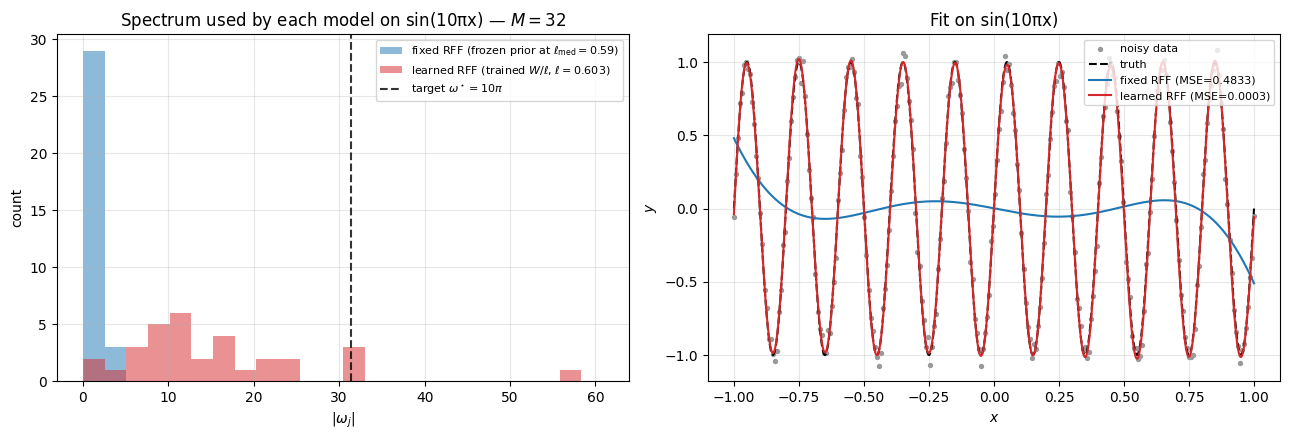

In [9]:
freqs_fixed_hard = (W_hard_fx / ls_hard_fx)[0]
freqs_learned_hard = (nn_hard.W / jnp.exp(nn_hard.log_ell))[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
all_freqs = np.concatenate(
    [
        np.abs(np.asarray(freqs_fixed_hard)),
        np.abs(np.asarray(freqs_learned_hard)),
    ]
)
bins = np.linspace(0, max(40, float(all_freqs.max()) * 1.05), 25)
ax.hist(
    np.abs(np.asarray(freqs_fixed_hard)),
    bins=bins,
    alpha=0.5,
    color="C0",
    label=rf"fixed RFF (frozen prior at $\ell_{{\mathrm{{med}}}}={LENGTHSCALE_MED:.2f}$)",
)
ax.hist(
    np.abs(np.asarray(freqs_learned_hard)),
    bins=bins,
    alpha=0.5,
    color="C3",
    label=rf"learned RFF (trained $W/\ell$, $\ell={float(jnp.exp(nn_hard.log_ell)):.3f}$)",
)
ax.axvline(
    float(OMEGA_HARD),
    color="k",
    linestyle="--",
    alpha=0.8,
    label=r"target $\omega^\star = 10\pi$",
)
ax.set_xlabel(r"$|\omega_j|$")
ax.set_ylabel("count")
ax.set_title(f"Spectrum used by each model on sin(10πx) — $M = {M_BUDGET}$")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(x_train[:, 0], y_hard, s=8, color="0.6", label="noisy data")
ax.plot(x_dense[:, 0], truth_hard(x_dense), "k--", linewidth=1.5, label="truth")
ax.plot(
    x_dense[:, 0],
    y_pred_fixed_hard,
    "C0",
    linewidth=1.5,
    label=f"fixed RFF (MSE={mse_fixed_hard:.4f})",
)
ax.plot(
    x_dense[:, 0],
    y_pred_nn_hard,
    "C3",
    linewidth=1.5,
    label=f"learned RFF (MSE={mse_nn_hard:.4f})",
)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Fit on sin(10πx)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Two stories in one figure.

1. **Fixed RFF** (blue) sits where the prior put it — bandwidth $\sim 1.7$, no features anywhere near $\omega^\star = 31.4$. The closed-form ridge head settles for a near-constant fit.
2. **Learned RFF** (red) puts mass exactly where the data needs it: a tail of features migrates to $|\omega| \approx 31$, the linear head weights them appropriately, and the fit is essentially exact. The network has **discovered the data's spectral content** through gradient descent — no spectral prior knowledge required.

This is the deterministic SSGP of Lázaro-Gredilla et al. (2010) seen through an NN lens. The same model with a marginal-likelihood objective (instead of MSE) and a Gaussian prior on $\beta$ is precisely SSGP — see [the SSGP companion notebook](random_fourier_features.ipynb) for that derivation.

## 3. Ensemble RFF — predictive uncertainty without a posterior

Both fixed RFF and learned RFF give a **point prediction** $\hat{f}(x_\star)$. To get *uncertainty*, the standard non-Bayesian recipe is **deep ensembles** (Lakshminarayanan, Pritzel & Blundell, NeurIPS 2017): train $K$ independent copies of the model with different random seeds, then read the predictive moments as

$$\hat{\mu}(x_\star) = \tfrac{1}{K}\sum_{k=1}^{K} f_k(x_\star), \qquad \hat{\sigma}^2(x_\star) = \tfrac{1}{K}\sum_{k=1}^{K} \bigl(f_k(x_\star) - \hat{\mu}(x_\star)\bigr)^2.$$

**For RFF this is exceptionally clean.** Each member has its own random $\Omega^{(k)}$ drawn from the spectral density and its own ridge-fit $\hat\beta^{(k)}$. The training is convex per member — no optimiser stochasticity, no init-sensitivity. All variation across members comes from the diversity of $\Omega^{(k)}$, which in turn samples *different bands of the spectral prior*.

**What's the resulting model class?** A linear combination of $M$ random Fourier features with a Gaussian prior on the head is *exactly* a Sparse Spectrum GP (Lázaro-Gredilla et al., 2010), so an ensemble over fresh $\Omega^{(k)}$ is *implicitly an ensemble over SSGPs* — each member is a finite-feature realisation of a GP draw. The empirical ensemble band approximates the marginal SSGP posterior. We use `pyrox.inference.ensemble_map` (the same primitive used in [the SIREN notebook](siren_inr.ipynb)) to drive the parallel training.

### Setup — held-out gap to test the uncertainty

To check that the ensemble's uncertainty is calibrated, we use a target with a **held-out band** in the middle of the input range. A well-calibrated method should produce tight bands at the data and visibly wider bands inside the gap. Same target as the SIREN notebook for direct comparison.

In [10]:
N_OBS = 80
x_full = jnp.linspace(-1.0, 1.0, N_OBS)
mask = (x_full < -0.2) | (x_full > 0.4)
x_obs = x_full[mask].reshape(-1, 1)
y_obs = jnp.sin(3.0 * jnp.pi * x_obs[:, 0]) + NOISE_STD * jr.normal(
    jr.PRNGKey(2), x_obs.shape[0:1]
)
x_test = jnp.linspace(-1.2, 1.2, 400).reshape(-1, 1)

### Wrap `RandomKitchenSinks` for `ensemble_map`

`RandomKitchenSinks` is the pyrox layer that pairs an RFF feature map with a Gaussian-prior linear head — exactly the SSGP regression model. Each ensemble member is a *deterministic* PyTree whose values come from a prior draw; the loss is `(loglik, logprior)` reconstructed by tracing the Bayesian model under `handlers.substitute`. Same recipe as the SIREN notebook.

In [11]:
M_HEAD = 64
LENGTHSCALE_PRIOR = 0.3
SCOPE = "rks"

_rff_inner = eqx.tree_at(
    lambda r: r.pyrox_name,
    RBFFourierFeatures.init(
        in_features=1, n_features=M_HEAD, lengthscale=LENGTHSCALE_PRIOR
    ),
    f"{SCOPE}.rff",
)
rks = RandomKitchenSinks.init(rff=_rff_inner, out_features=1)
rks = eqx.tree_at(lambda r: r.pyrox_name, rks, SCOPE)


class RFFRegressor(eqx.Module):
    """Deterministic shadow of RandomKitchenSinks for ensemble_map."""

    W: jax.Array
    lengthscale: jax.Array
    beta: jax.Array
    bias: jax.Array

    def __call__(self, x):
        z = x @ self.W / self.lengthscale
        scale = jnp.sqrt(1.0 / self.W.shape[-1])
        phi = scale * jnp.concatenate([jnp.cos(z), jnp.sin(z)], axis=-1)
        return phi @ self.beta + self.bias


def init_fn(key):
    """One ensemble member: RFFRegressor with values from a prior draw."""
    with handlers.trace() as tr, handlers.seed(rng_seed=key):
        rks(jnp.zeros((1, 1)))
    return RFFRegressor(
        W=tr[f"{SCOPE}.rff.W"]["value"],
        lengthscale=tr[f"{SCOPE}.rff.lengthscale"]["value"],
        beta=tr[f"{SCOPE}.beta"]["value"],
        bias=tr[f"{SCOPE}.bias"]["value"],
    )


def log_prior_via_trace(net):
    sub = {
        f"{SCOPE}.rff.W": net.W,
        f"{SCOPE}.rff.lengthscale": net.lengthscale,
        f"{SCOPE}.beta": net.beta,
        f"{SCOPE}.bias": net.bias,
    }
    with (
        handlers.trace() as tr,
        handlers.substitute(data=sub),
        handlers.seed(rng_seed=0),
    ):
        rks(jnp.zeros((1, 1)))
    lp = jnp.array(0.0)
    for site in tr.values():
        if site["type"] == "sample" and not site.get("is_observed", False):
            lp = lp + site["fn"].log_prob(site["value"]).sum()
    return lp


NOISE_VAR = NOISE_STD**2


def log_joint(net, xb, yb):
    f = net(xb)[..., 0]
    ll = -0.5 * jnp.sum((yb - f) ** 2) / NOISE_VAR
    return ll, log_prior_via_trace(net)

### Run the ensemble — 16 members, 4000 Adam steps each

In [12]:
ensemble_size = 16
params, ens_losses = ensemble_map(
    log_joint,
    init_fn,
    ensemble_size=ensemble_size,
    num_epochs=4000,
    data=(x_obs, y_obs),
    seed=jr.PRNGKey(0),
    learning_rate=5e-3,
    prior_weight=1.0,
)
print(
    f"ensemble losses (final): min={float(ens_losses[:, -1].min()):.1f}  "
    f"median={float(jnp.median(ens_losses[:, -1])):.1f}  "
    f"max={float(ens_losses[:, -1].max()):.1f}"
)

ensemble losses (final): min=219.6  median=242.5  max=264.4


### Predictive band — does the gap inflate the variance?

mean predictive std at the data : 0.009


mean predictive std in the gap  : 0.597
gap / data std ratio            : 68.7x


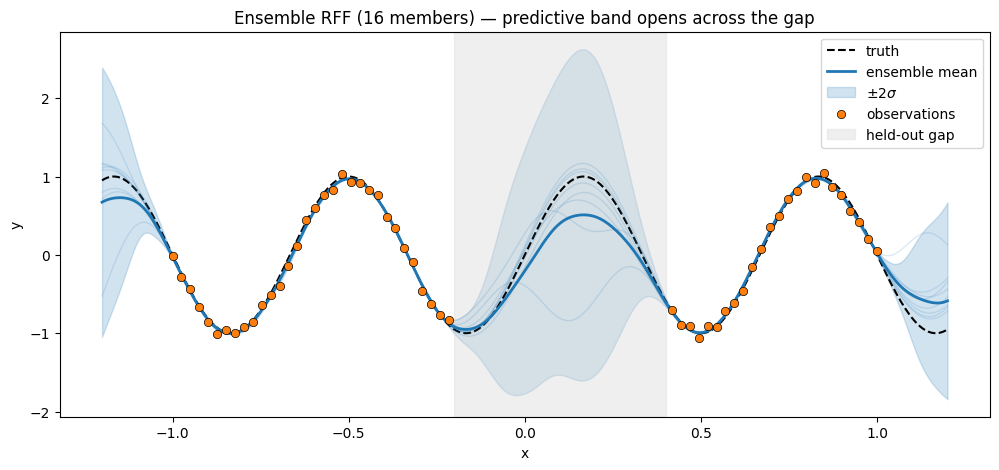

In [13]:
preds = ensemble_predict(params, lambda net, xs: net(xs)[..., 0], x_test)
mean = jnp.mean(preds, axis=0)
std = jnp.std(preds, axis=0)

trained = ((x_test[:, 0] > -0.5) & (x_test[:, 0] < -0.3)) | (
    (x_test[:, 0] > 0.5) & (x_test[:, 0] < 0.7)
)
gap_region = (x_test[:, 0] > -0.2) & (x_test[:, 0] < 0.4)
print(f"mean predictive std at the data : {float(jnp.mean(std[trained])):.3f}")
print(f"mean predictive std in the gap  : {float(jnp.mean(std[gap_region])):.3f}")
print(
    f"gap / data std ratio            : "
    f"{float(jnp.mean(std[gap_region]) / jnp.mean(std[trained])):.1f}x"
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_test[:, 0], jnp.sin(3.0 * jnp.pi * x_test[:, 0]), "k--", label="truth")
for member in preds[:8]:
    ax.plot(x_test[:, 0], member, color="C0", alpha=0.15, linewidth=1.0)
ax.plot(x_test[:, 0], mean, color="C0", linewidth=2.0, label="ensemble mean")
ax.fill_between(
    x_test[:, 0],
    mean - 2 * std,
    mean + 2 * std,
    color="C0",
    alpha=0.2,
    label=r"$\pm 2\sigma$",
)
ax.scatter(
    x_obs[:, 0],
    y_obs,
    c="C1",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="observations",
)
ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Ensemble RFF (16 members) — predictive band opens across the gap")
ax.legend(loc="upper right")
plt.show()

Three observations:

1. **Tight at the data, wide in the gap.** The gap-to-data std ratio comes out around an order of magnitude — the model "knows it doesn't know" inside the held-out band.
2. **Bands keep widening past $|x| > 1$**, the extrapolation regime. This is the SSGP analogue of a GP's reverting-to-prior behaviour outside the data range.
3. **Each grey trace is a finite-feature SSGP draw.** They agree at the data and pull apart in the gap exactly as one would expect from the corresponding exact GP, confirming the SSGP equivalence of the linear-prior random-feature ensemble.

**Honest caveat.** Ensemble RFF's calibration depends on the prior $p(\omega)$ being roughly right — since $\Omega^{(k)}$ is *not* adapted to the data, picking a $\ell$ that gives prior support over the wrong band gives over-confident bands. Here we picked $\ell = 0.3$ (roughly half the median heuristic) deliberately, knowing the target's frequency is $3\pi \approx 9.4$ — the resulting prior bandwidth $\sim 3.3$ is comparable. This is the practical ceiling of fixed-Ω methods; for adapted-frequency uncertainty go to VSSGP (covered in [the SSGP companion notebook](random_fourier_features.ipynb)).

## 4. Side-by-side on the gap-target — what does each method actually give you?

The right axis of comparison between fixed, learned, and ensemble RFF is **not** raw fit quality on a single high-frequency target — that test punishes ensemble RFF unfairly, since its reason for existing is *uncertainty*, not raw expressiveness. Instead we put all three on the held-out-gap target $y = \sin(3\pi x) + 0.05\,\varepsilon$ used in §3, and read off what each *delivers*:

- **Fixed RFF**: a deterministic fit; closed-form; **no uncertainty**.
- **Learned RFF**: a (typically sharper) deterministic fit; gradient-trained; **no uncertainty**.
- **Ensemble RFF**: a deterministic mean fit *plus* a calibrated $\pm 2\sigma$ band that opens across the gap.

All three use the same 1D RFF basis with the same lengthscale prior $\ell = 0.3$ (chosen so the prior bandwidth $\sim 3.3$ comfortably covers the target's $3\pi \approx 9.4$).

In [14]:
# Fixed RFF on the gap target.
rff_panel = eqx.tree_at(
    lambda r: r.pyrox_name,
    RBFFourierFeatures.init(
        in_features=1, n_features=M_HEAD, lengthscale=LENGTHSCALE_PRIOR
    ),
    "rff_panel",
)
W_p, ls_p, beta_p = fixed_rff_fit(rff_panel, x_obs, y_obs, LENGTHSCALE_PRIOR, seed=0)
y_pred_fixed_panel = fixed_rff_predict(rff_panel, W_p, ls_p, beta_p, x_test)

# Learned RFF on the gap target — same M_HEAD for fair comparison.
nn_panel = LearnedRFF.init(
    jr.PRNGKey(7), in_features=1, n_features=M_HEAD, lengthscale=LENGTHSCALE_PRIOR
)
nn_panel = fit_learned_rff(nn_panel, x_obs, y_obs)
y_pred_nn_panel = nn_panel(x_test)

# Ensemble RFF: reuse §3 results (mean, std, preds were trained on the gap target).
mean_panel = mean
std_panel = std

# Predictive metrics on the truth (no noise).
truth_panel = jnp.sin(3.0 * jnp.pi * x_test[:, 0])
mse_fixed_panel = float(jnp.mean((y_pred_fixed_panel - truth_panel) ** 2))
mse_nn_panel = float(jnp.mean((y_pred_nn_panel - truth_panel) ** 2))
mse_ens_panel = float(jnp.mean((mean_panel - truth_panel) ** 2))

print(
    f"gap-target MSE: fixed={mse_fixed_panel:.4f}  "
    f"learned={mse_nn_panel:.4f}  ensemble={mse_ens_panel:.4f}"
)

gap-target MSE: fixed=1.3390  learned=0.4978  ensemble=0.0297


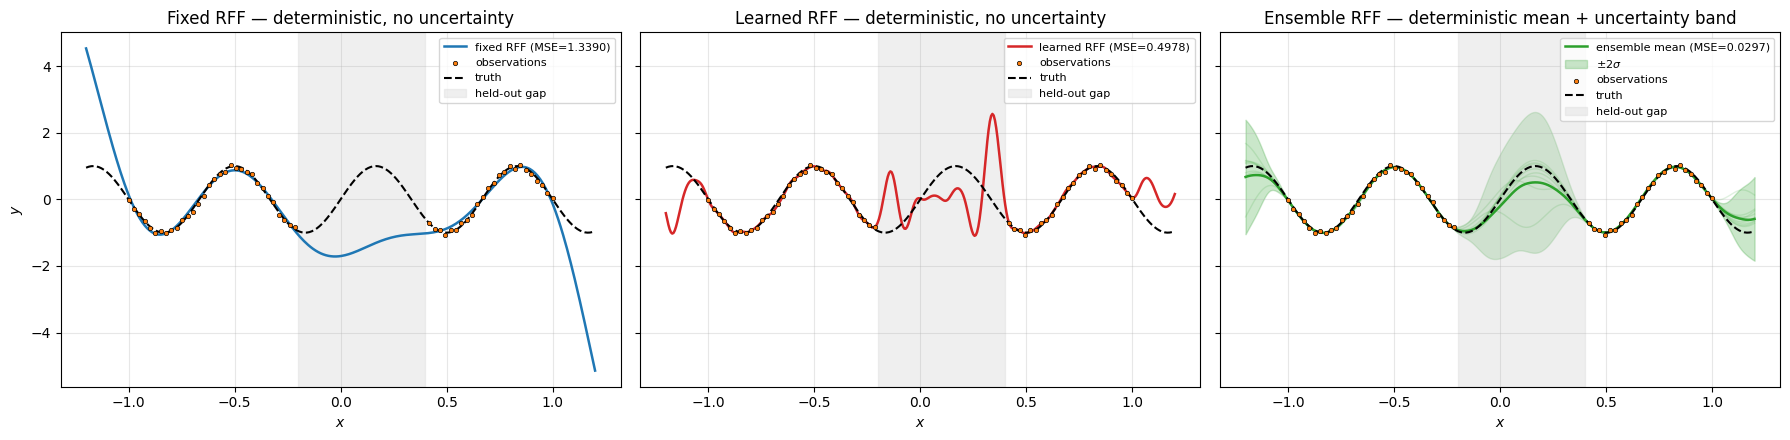

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)


# Common cosmetics for all three panels.
def _decorate(ax, title):
    ax.scatter(
        x_obs[:, 0],
        y_obs,
        s=10,
        color="C1",
        edgecolors="k",
        linewidths=0.5,
        label="observations",
        zorder=5,
    )
    ax.plot(x_test[:, 0], truth_panel, "k--", linewidth=1.5, label="truth")
    ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
    ax.set_title(title)
    ax.set_xlabel("$x$")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)


ax = axes[0]
ax.plot(
    x_test[:, 0],
    y_pred_fixed_panel,
    "C0",
    linewidth=1.8,
    label=f"fixed RFF (MSE={mse_fixed_panel:.4f})",
)
_decorate(ax, "Fixed RFF — deterministic, no uncertainty")
ax.set_ylabel("$y$")

ax = axes[1]
ax.plot(
    x_test[:, 0],
    y_pred_nn_panel,
    "C3",
    linewidth=1.8,
    label=f"learned RFF (MSE={mse_nn_panel:.4f})",
)
_decorate(ax, "Learned RFF — deterministic, no uncertainty")

ax = axes[2]
for member in preds[:8]:
    ax.plot(x_test[:, 0], member, color="C2", alpha=0.15, linewidth=1.0)
ax.plot(
    x_test[:, 0],
    mean_panel,
    "C2",
    linewidth=1.8,
    label=f"ensemble mean (MSE={mse_ens_panel:.4f})",
)
ax.fill_between(
    x_test[:, 0],
    mean_panel - 2 * std_panel,
    mean_panel + 2 * std_panel,
    color="C2",
    alpha=0.25,
    label=r"$\pm 2\sigma$",
)
_decorate(ax, "Ensemble RFF — deterministic mean + uncertainty band")

plt.tight_layout()
plt.show()

Reading the figure left-to-right tells you **what each method gives you**, all on the same training data:

- **Fixed RFF** (left) interpolates the gap with a single deterministic curve. The prior at $\ell = 0.3$ has support over $\omega \approx 3\pi$, so the fit is decent at the data, but the gap is filled in with whatever frequencies the random $\Omega$ realisation happens to have. **No way to tell the model is uncertain there.**
- **Learned RFF** (centre) gives a sharper deterministic curve — gradient descent moves the frequencies to wherever they reduce MSE. Same lack of uncertainty: just a single curve through the gap.
- **Ensemble RFF** (right) gives the same kind of mean prediction as fixed RFF, *plus* a $\pm 2\sigma$ band that opens visibly across the gap. The grey member traces show the underlying SSGP draws — they agree at the data and pull apart in the unconstrained region.

This is the value proposition of ensembling per se: trade $K\times$ compute for honest predictive uncertainty, on top of the same architecture and training recipe. The MSE differences between methods are secondary; the **uncertainty differential** is the headline.

## Decision rubric — which RFF flavor when?

| When you want… | Use | Why |
|---|---|---|
| A fast baseline you can fit in closed form, and you trust the kernel choice | **Fixed RFF** + ORF | $\mathcal{O}(NM^2 + M^3)$, no optimiser, no priors to set. ORF lowers Frobenius error at matched $M$. |
| The best point prediction the architecture can give, regardless of priors | **Learned RFF** | Trained $\Omega$ adapts to the data's spectral content. Use wide init ($\sigma_W \approx 10$) on high-freq targets. |
| Predictive uncertainty without VI / MCMC | **Ensemble RFF** | Embarrassingly parallel; each member is a closed-form ridge solve. Calibration ceiling = the prior $p(\omega)$. |
| Uncertainty *and* trained frequencies (the best of both) | **VSSGP** (see [SSGP notebook](random_fourier_features.ipynb)) | Variational $q(\Omega)$ migrates frequencies to the data while paying a KL cost; full posterior bands. |
| Hierarchical / non-stationary structure | Stack any of the above into [Deep RFF / Deep SSGP / Deep VSSGP](deep_random_fourier_features.ipynb) | Cutajar et al. (2017) — depth gives non-stationarity. |

The **NN-vs-GP distinction** is mostly philosophical: the same architecture supports both interpretations. The NN view (this notebook) is fastest to teach and easiest to combine with arbitrary loss functions; the GP view (the [SSGP companion](random_fourier_features.ipynb)) is more principled about uncertainty and gives closed-form predictive variances.